# Experiment: Million Songs Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge,RidgeCV
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV, KFold
from sklearn import preprocessing
from sklearn.model_selection import cross_val_score
from sklearn.utils import resample
import seaborn as sns

import torch
from torch.utils.data import Dataset,DataLoader
from torch import optim
import torch.nn as nn
import torch.nn.utils.prune as prune
import torch.nn.functional as F

import psutil, os, sys
import resource
import gc
import multiprocessing
import threading
import random



In [9]:
df=pd.read_csv('../../data/YearPredictionMSD/YearPredictionMSD.txt',header=None,sep = ',')
# smaller dataset - same split as RealData_MSD.ipynb
print(df.shape)
df = df.iloc[: int(0.1 * len(df))]
df.shape

(515345, 91)


(51534, 91)

In [29]:


tt = int(0.1 * len(df))

test=df.iloc[tt:] 

train, calibration = train_test_split(df[:tt], test_size=0.5, random_state=1)

train_y = train[0].to_numpy()
test_y = test[0].to_numpy()  # response:year
train_x = train.iloc[:, 1:].values
calibration_x = calibration.iloc[:, 1:].values
test_x = test.iloc[:, 1:].values
calibration_y = calibration.iloc[:, 0].to_numpy()

x_scaler = preprocessing.StandardScaler()
train_x = x_scaler.fit_transform(train_x)
calibration_x = x_scaler.transform(calibration_x)
test_x = x_scaler.transform(test_x)


nntrain_x = torch.from_numpy(train_x).float()
nntrain_y = torch.squeeze(torch.from_numpy(train_y).float()) 
nntest_x= torch.from_numpy(test_x).float()
nntest_y = torch.squeeze(torch.from_numpy(test_y).float())




train_x.shape, test_x.shape

((2576, 90), (46381, 90))

In [22]:
# Check for NaN/inf in data
print("NaN in train_x:", np.isnan(train_x).any())
print("NaN in train_y:", np.isnan(train_y).any())
print("Inf in train_x:", np.isinf(train_x).any())
print("Inf in train_y:", np.isinf(train_y).any())
print("train_y sample:", train_y[:5])
# Replace NaN/inf with column median (for X) or drop rows (for y)
train_x = np.nan_to_num(train_x, nan=0.0, posinf=0.0, neginf=0.0)  # or use column means
train_y = np.nan_to_num(train_y, nan=np.nanmedian(train_y), posinf=0.0, neginf=0.0)

NaN in train_x: False
NaN in train_y: False
Inf in train_x: False
Inf in train_y: False
train_y sample: [2009 2001 1992 1986 1976]


In [23]:
# =============================================
# Global Training Parameters
# =============================================
# Change these values once to apply to all algorithms
TRAINING_CONFIG = {
    'batch_size': 256,
    'max_epochs': 1000,
    'early_stop_window': 50,
    'lr': 1e-4,
    'momentum': 0.95,
    'weight_decay': 1e-3,
    'seed': 7199,
}

# =============================================
# Global Network Architecture Parameters
# =============================================
# Input dimension (determined by dataset)
INPUT_DIM = 90      # Number of features in dataset

# Hidden layer dimensions (shared across all models)
HIDDEN_DIM1 = 256    # First hidden layer dimension
HIDDEN_DIM2 = 128   # Second hidden layer dimension
HIDDEN_DIM3 = 64    # Third hidden layer dimension

In [24]:

class mydataset(Dataset):
    def __init__(self, x, y):
        self._x = x
        self._y = y
        self._len = len(x)

    def __getitem__(self, item): 
        return self._x[item], self._y[item]

    def __len__(self):
        return self._len

In [30]:
GLOBAL_SEED = 7199   # or any integer you choose

def set_global_seed(seed: int):
    if seed is None:
        seed = GLOBAL_SEED
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
def measure_time(func, *args, **kwargs):
    """
    Measure wall-clock time of func(*args, **kwargs).
    Returns (result, runtime_in_seconds).
    """
    t0 = time.time()
    result = func(*args, **kwargs)
    t1 = time.time()
    return result, (t1 - t0)


def measure_memory_cpu(func, *args, **kwargs):
    """
    Measure CPU memory during func() execution using a background polling thread.
    Returns: (result, delta_mb, peak_mb)
      - delta_mb: net RSS change (after - before). Can be negative if GC reclaims
                  memory during execution, so treat as informational only.
      - peak_mb:  peak RSS *increase* above baseline during execution (always >= 0).
                  Captured via a 50ms polling thread — the reliable metric.
    """
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    process = psutil.Process(os.getpid())
    mem_before = process.memory_info().rss

    peak_rss = [mem_before]
    stop_event = threading.Event()

    def _monitor():
        while not stop_event.is_set():
            try:
                cur = process.memory_info().rss
                if cur > peak_rss[0]:
                    peak_rss[0] = cur
            except Exception:
                pass
            stop_event.wait(0.05)

    monitor_thread = threading.Thread(target=_monitor, daemon=True)
    monitor_thread.start()

    result = func(*args, **kwargs)

    mem_after = process.memory_info().rss
    stop_event.set()
    monitor_thread.join()

    if mem_after > peak_rss[0]:
        peak_rss[0] = mem_after

    delta_mb = (mem_after - mem_before) / 1024**2
    peak_mb  = (peak_rss[0] - mem_before) / 1024**2

    return result, delta_mb, peak_mb




def measure_memory_gpu(func, *args, **kwargs):
    """
    Measure peak GPU memory allocated during func().
    Returns: (result, peak_MB or None)
    """
    if not torch.cuda.is_available():
        return func(*args, **kwargs), None

    torch.cuda.reset_peak_memory_stats()

    result = func(*args, **kwargs)

    peak_bytes = torch.cuda.max_memory_allocated()
    peak_mb = peak_bytes / 1024**2

    return result, peak_mb


# Random Feature

In [26]:
def sample_1d(pdf, gamma):
    if pdf=='G':
        w=torch.randn(1)*gamma
        return w
    elif pdf=='L':
        w=torch.distributions.laplace.Laplace(torch.tensor([0.0]), torch.tensor([1.0])).sample()*gamma
        return w
    elif pdf=='C':
        w=torch.distributions.cauchy.Cauchy(torch.tensor([0.0]), torch.tensor([1.0])).sample()*gamma
        return w
    
def sample(pdf, gamma, d):
    return torch.tensor([sample_1d(pdf, gamma) for _ in range(d)])

class RandomFourierFeature:
    """Random Fourier Feature
    Parameters
    ----------
    d : int
        Input space dimension
    D : int
        Feature space dimension
    W : shape (D,d)
    b : shape (D)
    kernel : char
        Kernel to use; 'G', 'L', or 'C'
    gamma : float
        pdf parameter
    """

    def __init__(self, d, D, W=None, b=None, kernel='G', gamma=1):

        self.d = d
        self.D = D
        self.gamma = gamma

        kernel = kernel.upper()
        if kernel not in ['G', 'L', 'C']:
            raise Exception('Invalid Kernel')
        self.kernel = kernel

        if W is None or b is None:
            self.create()
        else:
            self.__load(W, b)

    def __load(self, W, b):
        """Load from existing Arrays"""

        self.W = W.reshape([self.D, self.d])
        self.b = b
    

    def create(self):
        """Create a d->D fourier random feature"""

        self.b = torch.rand(self.D)*2*torch.pi
        self.W = sample(self.kernel, self.gamma, self.d*self.D).reshape(self.D,self.d)

    def transform(self, x):
        """Transform a vector using this feature
        Parameters
        ----------
        x : (shape=(n,d))
            to transform; must be single dimension vector
        Returns
        -------
        x : (shape=(n,D))
            Feature space transformation of x
        """
        #print(self.W.shape,self.b.reshape(-1,1).shape,x.shape)
        #print((self.W @ x.T).shape)
       
        result=torch.sqrt(torch.tensor([2.0/self.D])) * torch.cos( self.W @ x.T  + (self.b.reshape(-1,1) @ torch.ones(len(x)).reshape(1,-1))) 
        #print(result.T.shape)
        return result.T

In [31]:
def run_rf_ridge(train_x, train_y, test_x, test_y,
                 calibration_x, calibration_y,
                 D=500, gamma=0.4, seed=7199):
    """
    Train RF + Ridge and return (train_mse, test_mse).
    No timing or memory in here.
    """
    set_global_seed(seed)
    rff = RandomFourierFeature(d=train_x.shape[1], D=D,
                               kernel='G', gamma=gamma)

    total_x = np.vstack((train_x, calibration_x))
    total_y = np.hstack((train_y, calibration_y))

    # Random Fourier Features
    total_feature = rff.transform(total_x)
    test_feature  = rff.transform(test_x)

    # Ridge + CV
    model = Ridge()
    param_grid = {'alpha': [1e-4,1e-3,1e-2,1e-1,1]}
    kf = KFold(n_splits=5, shuffle=True)

    grid_search = GridSearchCV(model, param_grid, cv=kf)
    grid_search.fit(total_feature, total_y)

    best_model = grid_search.best_estimator_
    rf_pred_total = best_model.predict(total_feature)
    rf_pred_test  = best_model.predict(test_feature)

    train_mse = mean_squared_error(total_y, rf_pred_total)
    test_mse  = mean_squared_error(test_y, rf_pred_test)
    return train_mse, test_mse


def rf_core():
    return run_rf_ridge(train_x, train_y, test_x, test_y,
                        calibration_x, calibration_y,
                        D=500, gamma=0.4, seed=7199)

# Clear memory before measurement
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

(rf_result, rf_delta_cpu_mb, rf_peak_cpu_mb), rf_time = measure_time(
    lambda: measure_memory_cpu(rf_core)
)

rf_train_mse, rf_test_mse = rf_result

print("RF train MSE:", rf_train_mse)
print("RF test MSE:",  rf_test_mse)
print("RF runtime (s):", rf_time)
print("RF CPU Δ memory (MB):", rf_delta_cpu_mb)
print("RF CPU peak (MB):", rf_peak_cpu_mb)


/var/folders/z7/p968ccvd4d9c27v5n0y0qbyw0000gn/T/ipykernel_19626/462636501.py:74: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  result=torch.sqrt(torch.tensor([2.0/self.D])) * torch.cos( self.W @ x.T  + (self.b.reshape(-1,1) @ torch.ones(len(x)).reshape(1,-1)))


RF train MSE: 96.51271078956053
RF test MSE: 120.65542595462304
RF runtime (s): 1.0008800029754639
RF CPU Δ memory (MB): 656.15625
RF CPU peak (MB): 656.15625


## 1. DNN

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net,self).__init__()
        self.fc1 = nn.Linear(INPUT_DIM, HIDDEN_DIM1)
        self.fc2 = nn.Linear(HIDDEN_DIM1, HIDDEN_DIM2)
        self.fc3 = nn.Linear(HIDDEN_DIM2, HIDDEN_DIM3)
        self.fc4 = nn.Linear(HIDDEN_DIM3, 1)
    def forward(self,x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.fc4(x)





#initialize
def init_weights(m):
    if type(m) == nn.Conv2d:
        torch.nn.init.normal_(m.weight,mean=0,std=0.5)
    if type(m) == nn.Linear:
        torch.nn.init.uniform_(m.weight,a=0,b=0.1)
        m.bias.data.fill_(0)

def run_dnn(train_x, train_y, test_x, test_y,
            batch_size=256,
            max_epochs=1000,
            early_stop_window=50,
            lr=1e-4,
            momentum=0.9,
            weight_decay=1e-2,
            device=None,
            verbose=False,
            seed=7199):
    """
    Train the DNN and return (train_mse, test_mse, num_epochs_run).
    No timing or memory measurement inside.
    """

    # reproducibility
    set_global_seed(seed)

    # choose device
    if device is None:
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # numpy -> tensors
    nntrain_x = torch.from_numpy(train_x).float()
    nntrain_y = torch.from_numpy(train_y).float().squeeze()
    # nntest_x  = torch.from_numpy(test_x).float()
    # nntest_y  = torch.from_numpy(test_y).float().squeeze()

    train_loader = DataLoader(mydataset(nntrain_x, nntrain_y),
                              batch_size=batch_size, shuffle=True)
    # test_loader  = DataLoader(mydataset(nntest_x, nntest_y),
    #                           batch_size=batch_size, shuffle=False)

    # model, loss, optimizer
    net = Net().to(device)
    net.apply(init_weights)

    criterion = nn.MSELoss()
    optimizer = optim.SGD(net.parameters(),
                          lr=lr,
                          momentum=momentum,
                          weight_decay=weight_decay)

    dnn_trainloss = []
    dnn_testloss  = []

    for epoch in range(max_epochs):
        net.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            y_pred = net(x).squeeze()
            train_loss = criterion(y_pred, y)
            train_loss.backward()
            optimizer.step()

        # evaluate full train & test MSE (like your original code)
        net.eval()
        with torch.no_grad():
            # train MSE
            x0 = torch.from_numpy(train_x).float().to(device)
            pred_train = net(x0).squeeze().cpu().numpy()
            train_mse = mean_squared_error(train_y, pred_train)
            dnn_trainloss.append(train_mse)

            # test MSE
            x1 = torch.from_numpy(test_x).float().to(device)
            pred_test = net(x1).squeeze().cpu().numpy()
            test_mse = mean_squared_error(test_y, pred_test)
            dnn_testloss.append(test_mse)

        # early stopping: same idea as your code
        if epoch > early_stop_window:
            if float(dnn_trainloss[-1]) > max(dnn_trainloss[-early_stop_window:-1]):
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

        if verbose and epoch % 50 == 0:
            print(f"epoch {epoch:4d}  train MSE: {dnn_trainloss[-1]:.6f}  "
                  f"test MSE: {dnn_testloss[-1]:.6f}")

    num_epochs_run = len(dnn_trainloss)
    final_train_mse = dnn_trainloss[-1]
    final_test_mse  = dnn_testloss[-1]

    # Return training history for plotting
    return final_train_mse, final_test_mse, num_epochs_run, dnn_trainloss, dnn_testloss


In [34]:
def dnn_core():
    return run_dnn(train_x, train_y, test_x, test_y, **TRAINING_CONFIG)

# Clear memory before measurement
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# GPU wrapper inside, CPU wrapper around it, then time
((dnn_result, dnn_peak_gpu_mb), dnn_delta_cpu_mb, dnn_peak_cpu_mb), dnn_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(dnn_core)
    )
)


dnn_train_mse, dnn_test_mse, dnn_epochs, dnn_trainloss, dnn_testloss = dnn_result

print("DNN train MSE:", dnn_train_mse)
print("DNN test MSE:",  dnn_test_mse)
print("DNN time:", dnn_time)
print("DNN peak GPU (MB):", dnn_peak_gpu_mb)
print("DNN CPU Δ (MB):", dnn_delta_cpu_mb)
print("DNN CPU peak (MB):", dnn_peak_cpu_mb)


DNN train MSE: 108.05049133300781
DNN test MSE: 114.18232727050781
DNN time: 12.232092142105103
DNN peak GPU (MB): None
DNN CPU Δ (MB): -63.875
DNN CPU peak (MB): 0.03125


## 2. Resnet

In [63]:
print(train_x.std(axis=0))
print(np.min(train_x.std(axis=0)), np.max(train_x.std(axis=0)))
print(np.isnan(train_x).any(), np.isinf(train_x).any())
print(np.max(np.abs(train_x)))

print(train_y.mean(), train_y.std(), np.max(np.abs(train_y)))
print(np.isnan(train_y).any(), np.isinf(train_y).any())

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
0.9999999999999998 1.0000000000000002
False False
17.796374044636423
1998.5683229813665 10.34719437089587 2010
False False


In [103]:

def run_resnet(train_x, train_y, test_x, test_y,
               batch_size=256,
               max_epochs=1000,
               early_stop_window=50,
               lr=1e-4,
               momentum=0.9,
               weight_decay=1e-2,
               device=None,
               verbose=False,
               seed=7199):

    """
    Train a ResNet on tabular input and return:
        (final_train_mse, final_test_mse, num_epochs_run, res_trainloss, res_testloss)
    """

    # ========================
    # 1. Reproducibility
    # ========================
    set_global_seed(seed)

    # Determine device
    if device is None:
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # ========================
    # 2. Convert NumPy -> Tensors
    # ========================
    nntrain_x = torch.from_numpy(train_x).float()
    nntrain_y = torch.from_numpy(train_y).float().squeeze()

    train_loader = DataLoader(
        mydataset(nntrain_x, nntrain_y),
        batch_size=batch_size,
        shuffle=True
    )

    # ========================
    # 3. Model, Loss, Optimizer
    # ========================
    net = ResNet().to(device)
    net.apply(init_weights)

    criterion = nn.MSELoss()

    # Current optimizer: SGD
    optimizer = optim.SGD(
        net.parameters(),
        lr=lr,
        momentum=momentum,
        weight_decay=weight_decay
    )

    # If you want to test whether optimizer dynamics are the problem,
    # comment out SGD above and try Adam:
    # optimizer = optim.Adam(
    #     net.parameters(),
    #     lr=1e-4,
    #     weight_decay=1e-4
    # )

    # ========================
    # 4. Training Loop
    # ========================
    res_trainloss = []
    res_testloss = []
    stop_training = False

    for epoch in range(max_epochs):
        net.train()

        for batch_idx, (x, y) in enumerate(train_loader):
            x, y = x.to(device), y.to(device)

            # ---- Input checks ----
            if torch.isnan(x).any() or torch.isinf(x).any():
                print(f"[Epoch {epoch} Batch {batch_idx}] x has NaN/Inf")
                stop_training = True
                break

            if torch.isnan(y).any() or torch.isinf(y).any():
                print(f"[Epoch {epoch} Batch {batch_idx}] y has NaN/Inf")
                stop_training = True
                break

            optimizer.zero_grad()

            # ---- Forward ----
            y_pred = net(x).squeeze()

            if torch.isnan(y_pred).any() or torch.isinf(y_pred).any():
                print(f"[Epoch {epoch} Batch {batch_idx}] pred has NaN/Inf")
                stop_training = True
                break

            loss = criterion(y_pred, y)

            if torch.isnan(loss) or torch.isinf(loss):
                print(f"[Epoch {epoch} Batch {batch_idx}] loss has NaN/Inf")
                stop_training = True
                break

            # ---- Backward ----
            loss.backward()

            # ---- Gradient checks ----
            bad_grad = False
            for name, p in net.named_parameters():
                if p.grad is not None:
                    if torch.isnan(p.grad).any() or torch.isinf(p.grad).any():
                        print(f"[Epoch {epoch} Batch {batch_idx}] Gradient NaN/Inf in {name}")
                        bad_grad = True
                        break

            if bad_grad:
                stop_training = True
                break

            # ---- Gradient clipping ----
            torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)

            # ---- Update ----
            optimizer.step()

            # ---- Parameter checks ----
            bad_param = False
            for name, p in net.named_parameters():
                if torch.isnan(p).any() or torch.isinf(p).any():
                    print(f"[Epoch {epoch} Batch {batch_idx}] Parameter NaN/Inf in {name}")
                    bad_param = True
                    break

            if bad_param:
                stop_training = True
                break

        # Stop before evaluation if training already broke
        if stop_training:
            print(f"Training stopped at epoch {epoch}")
            break

        # ========================
        # 5. Evaluation
        # ========================
        net.eval()
        with torch.no_grad():
            x0 = torch.from_numpy(train_x).float().to(device)
            pred_train_t = net(x0).squeeze()

            if torch.isnan(pred_train_t).any() or torch.isinf(pred_train_t).any():
                print(f"[Epoch {epoch}] pred_train has NaN/Inf")
                stop_training = True
                break

            pred_train = pred_train_t.cpu().numpy()
            train_mse = mean_squared_error(train_y, pred_train)
            res_trainloss.append(train_mse)

            x1 = torch.from_numpy(test_x).float().to(device)
            pred_test_t = net(x1).squeeze()

            if torch.isnan(pred_test_t).any() or torch.isinf(pred_test_t).any():
                print(f"[Epoch {epoch}] pred_test has NaN/Inf")
                stop_training = True
                break

            pred_test = pred_test_t.cpu().numpy()
            test_mse = mean_squared_error(test_y, pred_test)
            res_testloss.append(test_mse)

        # ========================
        # 6. Early stopping
        # ========================
        if epoch > early_stop_window:
            recent_hist = res_trainloss[-early_stop_window:-1]
            if len(recent_hist) > 0 and res_trainloss[-1] > max(recent_hist):
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

        # ========================
        # 7. Logging
        # ========================
        if verbose and epoch % 50 == 0:
            print(f"epoch {epoch}")
            print(f"Train MSE: {train_mse}")
            print(f"Test  MSE: {test_mse}")

    # ========================
    # 8. Final outputs
    # ========================
    num_epochs_run = len(res_trainloss)

    if num_epochs_run == 0:
        final_train_mse = np.nan
        final_test_mse = np.nan
    else:
        final_train_mse = res_trainloss[-1]
        final_test_mse = res_testloss[-1]

    return final_train_mse, final_test_mse, num_epochs_run, res_trainloss, res_testloss

In [118]:

class ResidualBlock(nn.Module):
    def __init__(self,infeatures,outfeatures):
        super(ResidualBlock,self).__init__()
        self.infeatures = infeatures
        self.outfeatures = outfeatures
        self.fc1 = nn.Linear(infeatures,outfeatures)
        self.fc2 = nn.Linear(infeatures,outfeatures)
    
    def forward(self, x):
        y = self.fc1(x)
        y= F.relu(y)
        x = self.fc2(x)
        return F.relu(x+y)


class ResNet(nn.Module): 
    def __init__(self):
        super(ResNet, self).__init__()
        self.rblock1 = ResidualBlock(INPUT_DIM, HIDDEN_DIM1)
        self.rblock2 = ResidualBlock(HIDDEN_DIM1, HIDDEN_DIM2)
        self.rblock3 = ResidualBlock(HIDDEN_DIM2, HIDDEN_DIM3)
        self.fc4 = nn.Linear(HIDDEN_DIM3, 1)
    
 
    def forward(self, x):
        x = self.rblock1(x)
        x = self.rblock2(x)
        x = self.rblock3(x)
        return self.fc4(x)
#initialize
def init_weights(m):
    if type(m) == nn.Conv2d:
        torch.nn.init.normal_(m.weight,mean=0,std=0.5)
    if type(m) == nn.Linear:
        torch.nn.init.uniform_(m.weight,a=0,b=0.1)
        m.bias.data.fill_(0.01)

In [119]:
def run_resnet(train_x, train_y, test_x, test_y,
               batch_size=256,
               max_epochs=1000,
               early_stop_window=50,
               lr=1e-4,
               momentum=0.9,
               weight_decay=1e-2,
               device=None,
               verbose=False,
               seed=7199):
    """
    Train a ResNet on tabular input and return:
        (train_mse, test_mse, num_epochs_run)
    No timing or memory measurements inside.
    """

    # ========================
    # 1. Reproducibility
    # ========================
    set_global_seed(seed)

    # Determine device
    if device is None:
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # ========================
    # 2. Convert NumPy → Tensors
    # ========================
    nntrain_x = torch.from_numpy(train_x).float()
    nntrain_y = torch.from_numpy(train_y).float().squeeze()
    nntest_x  = torch.from_numpy(test_x).float()
    nntest_y  = torch.from_numpy(test_y).float().squeeze()

    train_loader = DataLoader(
        mydataset(nntrain_x, nntrain_y),
        batch_size=batch_size, shuffle=True
    )

    test_loader = DataLoader(
        mydataset(nntest_x, nntest_y),
        batch_size=batch_size, shuffle=False
    )

    # ========================
    # 3. Model, Loss, Optimizer
    # ========================
    net = ResNet().to(device)
    net.apply(init_weights)      # keep your initialization

    criterion = nn.MSELoss()

    optimizer = optim.SGD(
        net.parameters(),
        lr=lr,
        momentum=momentum,
        weight_decay=weight_decay
    )

    # ========================
    # 4. Training Loop
    # ========================
    res_trainloss = []
    res_testloss  = []
    for epoch in range(max_epochs):

        # ---- Training ----
        net.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            y_pred = net(x).squeeze()
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()

        # ---- Evaluation ----
        net.eval()
        with torch.no_grad():
            # full train MSE
            x0 = torch.from_numpy(train_x).float().to(device)
            pred_train = net(x0).squeeze().cpu().numpy()
            train_mse = mean_squared_error(train_y, pred_train)
            res_trainloss.append(train_mse)

            # full test MSE
            x1 = torch.from_numpy(test_x).float().to(device)
            pred_test = net(x1).squeeze().cpu().numpy()
            test_mse = mean_squared_error(test_y, pred_test)
            res_testloss.append(test_mse)

        # ---- Early Skipping ----
        if epoch > early_stop_window:
            if res_trainloss[-1] > max(res_trainloss[-early_stop_window:-1]):
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

        # ---- Optional Printing ----
        if verbose and epoch % 50 == 0:
            print(f"""epoch {epoch}
                Train MSE: {train_mse}
                Test  MSE: {test_mse}
            """)

    # final metrics
    num_epochs_run = len(res_trainloss)
    final_train_mse = res_trainloss[-1]
    final_test_mse  = res_testloss[-1]
    return final_train_mse, final_test_mse, num_epochs_run, res_trainloss, res_testloss


In [120]:

TRAINING_CONFIG = {
    'batch_size': 1024,
    'max_epochs': 1000,
    'early_stop_window': 50,
    'lr': 1e-4,
    'momentum': 0.95,
    'weight_decay': 1e-3,
    'seed': 7199,
}

def resnet_core():
    return run_resnet(train_x, train_y, test_x, test_y, **TRAINING_CONFIG)

# Clear memory before measurement
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

((res_result, res_peak_gpu), res_delta_cpu, res_peak_cpu), res_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(resnet_core)
    )
)

res_train_mse, res_test_mse, res_epochs, res_trainloss, res_testloss= res_result

print("ResNet Train MSE:", res_train_mse)
print("ResNet Test  MSE:", res_test_mse)
print("ResNet Epochs:", res_epochs)
print("ResNet Time:", res_time)
print("ResNet CPU ΔMB:", res_delta_cpu)
print("ResNet CPU peak (MB):", res_peak_cpu)
print("ResNet GPU peak MB:", res_peak_gpu)



ResNet Train MSE: 108.08250427246094
ResNet Test  MSE: 114.20926666259766
ResNet Epochs: 1000
ResNet Time: 20.200886964797974
ResNet CPU ΔMB: 24.03125
ResNet CPU peak (MB): 24.03125
ResNet GPU peak MB: None


## 2.5 DKL (NN feature extractor + GP)

In [121]:
import gpytorch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

class DKLFeatureExtractor(torch.nn.Module):
    def __init__(self, in_dim=INPUT_DIM):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(in_dim, HIDDEN_DIM1),
            torch.nn.ReLU(),
            torch.nn.Linear(HIDDEN_DIM1, HIDDEN_DIM2),
            torch.nn.ReLU(),
            torch.nn.Linear(HIDDEN_DIM2, HIDDEN_DIM3),
            torch.nn.ReLU(),
            torch.nn.Linear(HIDDEN_DIM3, 2),
        )
    def forward(self, x):
        return self.net(x)

class DKLExactGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, feature_extractor):
        super().__init__(train_x, train_y, likelihood)
        self.feature_extractor = feature_extractor
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())
    def forward(self, x):
        z = self.feature_extractor(x)
        mean_x = self.mean_module(z)
        covar_x = self.covar_module(z)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

def run_dkl(train_x, train_y, test_x, test_y, training_iter=300, seed=7199):
    """Train DKL and return (train_mse, test_mse)"""
    set_global_seed(seed)
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    train_x = np.asarray(train_x)
    train_y = np.asarray(train_y).ravel()
    test_x = np.asarray(test_x)
    test_y = np.asarray(test_y).ravel()
    train_x_t = torch.from_numpy(train_x).float().to(device)
    train_y_t = torch.from_numpy(train_y).float().squeeze().to(device)
    test_x_t = torch.from_numpy(test_x).float().to(device)
    dkl_likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
    feat = DKLFeatureExtractor(in_dim=train_x_t.shape[1]).to(device)
    dkl_model = DKLExactGP(train_x_t, train_y_t, dkl_likelihood, feat).to(device)
    dkl_model.train()
    dkl_likelihood.train()
    optimizer = torch.optim.Adam([
        {'params': dkl_model.feature_extractor.parameters(), 'lr': 1e-3},
        {'params': dkl_model.covar_module.parameters()},
        {'params': dkl_model.mean_module.parameters()},
        {'params': dkl_likelihood.parameters()},
    ], lr=0.05)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(dkl_likelihood, dkl_model)
    for i in range(training_iter):
        optimizer.zero_grad()
        output = dkl_model(train_x_t)
        loss = -mll(output, train_y_t)
        loss.backward()
        optimizer.step()
    dkl_model.eval()
    dkl_likelihood.eval()
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred_train = dkl_likelihood(dkl_model(train_x_t)).mean
        pred_test = dkl_likelihood(dkl_model(test_x_t)).mean
    train_mse = mean_squared_error(train_y, pred_train.detach().cpu().numpy())
    test_mse = mean_squared_error(test_y, pred_test.detach().cpu().numpy())
    return train_mse, test_mse

def dkl_core():
    return run_dkl(train_x, train_y, test_x, test_y)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

((dkl_result, dkl_peak_gpu), dkl_delta_cpu, dkl_peak_cpu), dkl_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(dkl_core)
    )
)
dkl_train_mse, dkl_test_mse = dkl_result
print("DKL Train MSE:", dkl_train_mse)
print("DKL Test  MSE:", dkl_test_mse)
print("DKL Time (s):", dkl_time)
print("DKL CPU Δ (MB):", dkl_delta_cpu)
print("DKL GPU peak (MB):", dkl_peak_gpu)


/Users/wanghd/Desktop/Research/Dai/Multi_layer_kernel_machines/Multi-Layer-Kernel-Machine/venv/lib/python3.13/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


DKL Train MSE: 4.4770612716674805
DKL Test  MSE: 270.49713134765625
DKL Time (s): 18.564589738845825
DKL CPU Δ (MB): 1048.15625
DKL GPU peak (MB): None


## 2.6 DGP (Deep Gaussian Process)

In [108]:
class DGPLayer(gpytorch.models.deep_gps.DeepGPLayer):
    def __init__(self, input_dims, output_dims, inducing_points):
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            inducing_points.size(0)
        )
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self,
            inducing_points,
            variational_distribution,
            learn_inducing_locations=True
        )
        super().__init__(variational_strategy, input_dims, output_dims)
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

def run_dgp(train_x, train_y, test_x, test_y,
            training_iter=1000, batch_size=256, num_inducing=128, hidden_dim=5, seed=7199):
    """Train Deep GP and return (train_mse, test_mse)"""
    set_global_seed(seed)
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    train_x = np.asarray(train_x)
    train_y = np.asarray(train_y).ravel()
    test_x = np.asarray(test_x)
    test_y = np.asarray(test_y).ravel()
    train_x_t = torch.from_numpy(train_x).float().to(device)
    train_y_t = torch.from_numpy(train_y).float().squeeze().to(device)
    test_x_t = torch.from_numpy(test_x).float().to(device)
    class TwoLayerDGP(gpytorch.models.deep_gps.DeepGP):
        def __init__(self, train_x_t, num_inducing, hidden_dim):
            super().__init__()
            inducing_1 = train_x_t[torch.randperm(train_x_t.size(0))[:num_inducing]]
            inducing_2 = torch.randn(num_inducing, hidden_dim).to(device)
            self.hidden_layer = DGPLayer(
                input_dims=train_x_t.shape[1],
                output_dims=hidden_dim,
                inducing_points=inducing_1
            )
            self.output_layer = DGPLayer(
                input_dims=hidden_dim,
                output_dims=None,
                inducing_points=inducing_2
            )
            self.likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
        def forward(self, inputs):
            hidden_rep = self.hidden_layer(inputs)
            output = self.output_layer(hidden_rep)
            return output
        def predict(self, x):
            self.eval()
            self.likelihood.eval()
            with torch.no_grad(), gpytorch.settings.num_likelihood_samples(16):
                preds = self.likelihood(self(x))
                return preds.mean.mean(dim=0)
    dgp_model = TwoLayerDGP(train_x_t, num_inducing, hidden_dim).to(device)
    dgp_model.train()
    dgp_model.likelihood.train()
    optimizer = torch.optim.Adam(dgp_model.parameters(), lr=0.01)
    elbo = gpytorch.mlls.DeepApproximateMLL(
        gpytorch.mlls.VariationalELBO(dgp_model.likelihood, dgp_model, num_data=train_x_t.size(0))
    )
    for i in range(training_iter):
        perm = torch.randperm(train_x_t.size(0), device=device)
        for j in range(0, train_x_t.size(0), batch_size):
            idx = perm[j:j+batch_size]
            optimizer.zero_grad()
            output = dgp_model(train_x_t[idx])
            loss = -elbo(output, train_y_t[idx])
            loss.backward()
            optimizer.step()
    pred_train = dgp_model.predict(train_x_t).detach().cpu().numpy()
    pred_test = dgp_model.predict(test_x_t).detach().cpu().numpy()
    train_mse = mean_squared_error(train_y, pred_train)
    test_mse = mean_squared_error(test_y, pred_test)
    return train_mse, test_mse

def dgp_core():
    return run_dgp(train_x, train_y, test_x, test_y)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

((dgp_result, dgp_peak_gpu), dgp_delta_cpu, dgp_peak_cpu), dgp_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(dgp_core)
    )
)
dgp_train_mse, dgp_test_mse = dgp_result
print("DGP Train MSE:", dgp_train_mse)
print("DGP Test  MSE:", dgp_test_mse)
print("DGP Time (s):", dgp_time)
print("DGP CPU Δ (MB):", dgp_delta_cpu)
print("DGP GPU peak (MB):", dgp_peak_gpu)


DGP Train MSE: 316017.3125
DGP Test  MSE: 316431.625
DGP Time (s): 87.13405513763428
DGP CPU Δ (MB): 213.46875
DGP GPU peak (MB): None


# 3. MLKM

In [122]:
# D1, D2, D3 now passed as parameters to run_mlkm for flexibility

def run_mlkm(train_x, train_y, test_x, test_y,
             D1=500, D2=500, D3=500,  # RFF feature dimensions
             batch_size=256,
             max_epochs=1000,
             early_stop_window=50,
             lr=1e-4,
             momentum=0.95,
             weight_decay=1e-3,
             device=None,
             verbose=False,
             seed=7199):

    # -----------------------
    # 1. Reproducibility
    # -----------------------
    set_global_seed(seed)

    # Device

    # -----------------------
    # 2. NumPy -> Tensors
    # -----------------------
    nntrain_x = torch.from_numpy(train_x).float()
    nntrain_y = torch.from_numpy(train_y).float().squeeze()
    # nntest_x = torch.from_numpy(test_x).float()
    # nntest_y = torch.from_numpy(test_y).float().squeeze()

    train_loader = DataLoader(
        mydataset(nntrain_x, nntrain_y),
        batch_size=batch_size, shuffle=True
    )
    # test_loader = DataLoader(
    #     mydataset(nntest_x, nntest_y),
    #     batch_size=batch_size, shuffle=False
    # )

    # -----------------------
    # 3. Random Fourier Features
    # -----------------------
    #rff1 = RandomFourierFeature(INPUT_DIM, HIDDEN_DIM1 * 20, kernel='G', gamma=0.1)
    rff1 = RandomFourierFeature(INPUT_DIM, D1, kernel='G', gamma=0.1)
    rff2 = RandomFourierFeature(HIDDEN_DIM1, D2, kernel='G', gamma=0.4)
    rff3 = RandomFourierFeature(HIDDEN_DIM2, D3, kernel='G', gamma=0.4)



    # -----------------------
    # 4. Define KernelNet inside function to capture rff1, rff2, rff3
    # -----------------------
    class KernelNet(nn.Module):
        def __init__(self):
            super().__init__()
            # self.fc1 = nn.Linear(HIDDEN_DIM1 * 20, HIDDEN_DIM1)
            self.fc1 = nn.Linear(D1, HIDDEN_DIM1)   # -> 16
            self.fc2 = nn.Linear(D2, HIDDEN_DIM2)   # -> 64
            self.fc3 = nn.Linear(D3, HIDDEN_DIM3)   # -> 16
            self.out = nn.Linear(HIDDEN_DIM3, 1)

        def forward(self, x):
            x = self.fc1(rff1.transform(x))   # INPUT -> D1 -> 16
            x = self.fc2(rff2.transform(x))   # 16 -> D2 -> 64
            x = self.fc3(rff3.transform(x))   # 64 -> D3 -> 16
            return self.out(x)                # 16 -> 1
    # 5. Model, Loss, Optimizer
    # -----------------------
    net = KernelNet().to(device)
    net.apply(init_weights)
    criterion = nn.MSELoss()
    optimizer = optim.SGD(
        net.parameters(),
        lr=lr,
        momentum=momentum,
        weight_decay=weight_decay
    )

    # -----------------------
    # 6. Training Loop
    # -----------------------
    kernelnn_trainloss = []
    kernelnn_testloss = []

    for epoch in range(max_epochs):
        net.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            y_pred = net(x).squeeze()
            train_loss = criterion(y_pred, y)
            train_loss.backward()
            optimizer.step()

        # ---- Evaluation (train + test MSE) ----
        net.eval()
        with torch.no_grad():
            # train MSE
            x0 = torch.from_numpy(train_x).float().to(device)
            pred_train = net(x0).squeeze().cpu().numpy()
            train_mse = mean_squared_error(train_y, pred_train)
            kernelnn_trainloss.append(train_mse)

            # test MSE
            x1 = torch.from_numpy(test_x).float().to(device)
            pred_test = net(x1).squeeze().cpu().numpy()
            test_mse = mean_squared_error(test_y, pred_test)
            kernelnn_testloss.append(test_mse)

        # ---- Early stopping ----
        if epoch > early_stop_window:
            if kernelnn_trainloss[-1] > max(kernelnn_trainloss[-early_stop_window:-1]):
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

    num_epochs_run = len(kernelnn_trainloss)
    final_train_mse = kernelnn_trainloss[-1]
    final_test_mse = kernelnn_testloss[-1]

    # Return additional outputs for conformal prediction
    return final_train_mse, final_test_mse, num_epochs_run, net, optimizer, kernelnn_trainloss, kernelnn_testloss, device

In [123]:
def mlkm_core():
    return run_mlkm(train_x, train_y, test_x, test_y, **TRAINING_CONFIG)

# Clear memory before measurement
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

((mlkm_result, mlkm_peak_gpu), mlkm_delta_cpu, mlkm_peak_cpu), mlkm_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(mlkm_core)
    )
)

# Unpack all results including model/optimizer for conformal prediction
mlkm_train_mse, mlkm_test_mse, mlkm_epochs, mlkm_net, mlkm_optimizer, mlkm_trainloss, mlkm_testloss, mlkm_device = mlkm_result


In [124]:
print("MLKM train MSE:", mlkm_train_mse)
print("MLKM test  MSE:", mlkm_test_mse)
print("MLKM epochs run:", mlkm_epochs)
print("MLKM time:", mlkm_time)
print("MLKM CPU ΔMB:", mlkm_delta_cpu)
print("MLKM CPU peak (MB):", mlkm_peak_cpu)
print("MLKM GPU peak MB:", mlkm_peak_gpu)


MLKM train MSE: 112.00608825683594
MLKM test  MSE: 117.15579986572266
MLKM epochs run: 142
MLKM time: 28.029730081558228
MLKM CPU ΔMB: -175.21875
MLKM CPU peak (MB): 331.21875
MLKM GPU peak MB: None


## 4. Residual multilayer learning

In [145]:
def run_reskernelnet(train_x, train_y, test_x, test_y,
                     batch_size=128,
                     D1=500, D2=None, D3=None, D4=None, # D2, D3 auto-set to HIDDEN_DIM1, HIDDEN_DIM2
                     max_epochs=1000,
                     early_stop_window=50,
                     lr=1e-4,
                     momentum=0.9,
                     weight_decay=1e-2,
                     device=None,
                     verbose=False,
                     seed=7199):
    """
    Train ResKernelNet and return (train_mse, test_mse, num_epochs_run)
    Note: D2 and D3 must equal HIDDEN_DIM1 and HIDDEN_DIM2 for residual connections
    """
    set_global_seed(seed)
    
    # D2 and D3 must match hidden dims for residual connections
    if D2 is None:
        D2 = HIDDEN_DIM1
    if D3 is None:
        D3 = HIDDEN_DIM2
    if D4 is None:
        D4 = HIDDEN_DIM3
    if device is None:
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    # Convert to tensors
    nntrain_x = torch.from_numpy(train_x).float()
    nntrain_y = torch.from_numpy(train_y).float().squeeze()
    
    train_loader = DataLoader(mydataset(nntrain_x, nntrain_y), batch_size=batch_size, shuffle=True)
    

    # ------------------------
    # Random Fourier Features
    # IMPORTANT:
    # In YOUR block, rff.transform(...) is applied AFTER fc1,
    # so each rff must accept the block's outfeatures as input.
    # ------------------------
    rff1 = RandomFourierFeature(HIDDEN_DIM1, D2, kernel='G', gamma=0.4)
    rff2 = RandomFourierFeature(HIDDEN_DIM2, D3, kernel='G', gamma=0.4)
    rff3 = RandomFourierFeature(HIDDEN_DIM3, D4, kernel='G', gamma=0.4)

    class ResKernelBlock(nn.Module):
        def __init__(self, infeatures, d_phi, outfeatures, rff):
            super().__init__()
            self.infeatures = infeatures
            self.outfeatures = outfeatures
            self.d_phi = d_phi
            self.rff = rff

            # First map input -> outfeatures
            self.fc1 = nn.Linear(infeatures, outfeatures)

            # Then RFF(outfeatures -> d_phi), then map d_phi -> outfeatures
            self.fc2 = nn.Linear(d_phi, outfeatures)

        def forward(self, x):
            x = self.fc1(x)               # shape: (batch, outfeatures)
            y = self.rff.transform(x)     # shape: (batch, d_phi)
            y = self.fc2(y)               # shape: (batch, outfeatures)
            return x + y

    class ResKernelNet(nn.Module):
        def __init__(self):
            super().__init__()
            self.b1 = ResKernelBlock(INPUT_DIM,   D2, HIDDEN_DIM1, rff1)
            self.b2 = ResKernelBlock(HIDDEN_DIM1, D3, HIDDEN_DIM2, rff2)
            self.b3 = ResKernelBlock(HIDDEN_DIM2, D4, HIDDEN_DIM3, rff3)
            self.fc3 = nn.Linear(HIDDEN_DIM3, 1)

        def forward(self, x):
            x = self.b1(x)
            x = self.b2(x)
            x = self.b3(x)
            return self.fc3(x)
    
    # Initialize model
    net = ResKernelNet().to(device)
    torch.manual_seed(1)
    
    criterion = nn.MSELoss()
    optimizer = optim.SGD(net.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    
    reskernel_trainloss = []
    reskernel_testloss = []
    
    for epoch in range(max_epochs):
        net.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            y_pred = net(x).squeeze()
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()
        
        # Evaluate
        net.eval()
        with torch.no_grad():
            x0 = torch.from_numpy(train_x).float().to(device)
            pred_train = net(x0).squeeze().cpu().numpy()
            train_mse = mean_squared_error(train_y, pred_train)
            reskernel_trainloss.append(train_mse)
            
            x1 = torch.from_numpy(test_x).float().to(device)
            pred_test = net(x1).squeeze().cpu().numpy()
            test_mse = mean_squared_error(test_y, pred_test)
            reskernel_testloss.append(test_mse)
        
        # Early stopping
        if epoch > early_stop_window:
            if reskernel_trainloss[-1] > max(reskernel_trainloss[-early_stop_window:-1]):
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break
        
        if verbose and epoch % 50 == 0:
            print(f"epoch {epoch}: Train MSE={train_mse:.6f}, Test MSE={test_mse:.6f}")
    
    num_epochs_run = len(reskernel_trainloss)
    final_train_mse = reskernel_trainloss[-1]
    final_test_mse = reskernel_testloss[-1]
    
    # Return training history for plotting
    return final_train_mse, final_test_mse, num_epochs_run, reskernel_trainloss, reskernel_testloss


def reskernelnet_core():
    return run_reskernelnet(train_x, train_y, test_x, test_y, **TRAINING_CONFIG)

# Clear memory before measurement
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Measure with wrappers
((rkn_result, rkn_peak_gpu), rkn_delta_cpu, rkn_peak_cpu), rkn_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(reskernelnet_core)
    )
)

rkn_train_mse, rkn_test_mse, rkn_epochs, rkn_trainloss, rkn_testloss = rkn_result

print("ResKernelNet Train MSE:", rkn_train_mse)
print("ResKernelNet Test  MSE:", rkn_test_mse)
print("ResKernelNet Epochs:", rkn_epochs)
print("ResKernelNet Time (s):", rkn_time)
print("ResKernelNet CPU Δ (MB):", rkn_delta_cpu)
print("ResKernelNet CPU peak (MB):", rkn_peak_cpu)
print("ResKernelNet GPU peak (MB):", rkn_peak_gpu)

ValueError: Input contains NaN.

In [133]:
train_loader = DataLoader(mydataset(nntrain_x, nntrain_y),batch_size=1024, shuffle=True)
test_loader = DataLoader(mydataset(nntest_x, nntest_y),batch_size=1024, shuffle=False)

rff0=RandomFourierFeature(90,256,kernel='C',gamma=0.02)
rff1=RandomFourierFeature(128,128,kernel='G',gamma=0.1)
rff2=RandomFourierFeature(64,64,kernel='G',gamma=0.5)


class ResidualBlock(nn.Module):
    def __init__(self,infeatures,outfeatures,rff):
        super(ResidualBlock,self).__init__()
        self.infeatures = infeatures
        self.outfeatures = outfeatures
        self.rff=rff
        
        self.fc1 = nn.Linear(infeatures,outfeatures)
        self.fc2 = nn.Linear(outfeatures,outfeatures)
    
    def forward(self, x):
        rff=self.rff
        x = self.fc1(x)
        y = rff.transform(x)
        y = self.fc2(y)
        return x+y

class ResKernelNet(nn.Module): 
    def __init__(self):
        super(ResKernelNet, self).__init__()
        self.rblock1 = ResidualBlock(256,128,rff1)
        self.rblock2 = ResidualBlock(128,64,rff2)
        self.fc3 =nn.Linear(64,1)
 
    def forward(self, x):
        x = rff0.transform(x)
        x = self.rblock1(x)
        x = self.rblock2(x)
        return self.fc3(x)

#initialize
def init_weights(m):
    if type(m) == nn.Conv2d:
        torch.nn.init.normal_(m.weight,mean=0,std=0.5)
    if type(m) == nn.Linear:
        torch.nn.init.uniform_(m.weight,a=0,b=1)
        m.bias.data.fill_(0.01)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = ResKernelNet()
net = net.to(device)
torch.manual_seed(1)
#net.apply(init_weights)
print(net)
criterion=nn.MSELoss() 
optimizer=optim.SGD(net.parameters(),lr=1e-6,momentum=0.9,weight_decay=1e-2) #optim.Adam(...)

loss=[]
reskernel_trainloss=[]
reskernel_testloss=[]
t0 = time.time()
for epoch in range(20): 
    for x, y in train_loader: #for batch, (x, y) in enumerate(train_loader): 
        x, y = x.to(device), y.to(device)
        # Compute prediction error
        y_pred = net(x)
        y_pred = torch.squeeze(y_pred)
        train_loss = criterion(y_pred, y)
        loss.append(train_loss)
        # Backpropagation
        optimizer.zero_grad() 
        train_loss.backward()
        optimizer.step()
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        y_test_pred = net(x)
        y_test_pred = torch.squeeze(y_test_pred)

        test_loss = criterion(y_test_pred,y)
            
    if epoch>5 and float(test_loss)>max(reskernel_testloss[-5:-1]):
        break
    
    
    if epoch % 2 == 0:         
        print(f'''epoch {epoch}
            Train set - loss: {train_loss}
            Test  set - loss: {test_loss}
            ''')
    reskernel_trainloss.append(float(train_loss))
    reskernel_testloss.append(float(test_loss))
        
    
dnn_fit = time.time() - t0
print("Residual KernelNet complexity and model fitted in %.3f s" % dnn_fit)

ResKernelNet(
  (rblock1): ResidualBlock(
    (fc1): Linear(in_features=256, out_features=128, bias=True)
    (fc2): Linear(in_features=128, out_features=128, bias=True)
  )
  (rblock2): ResidualBlock(
    (fc1): Linear(in_features=128, out_features=64, bias=True)
    (fc2): Linear(in_features=64, out_features=64, bias=True)
  )
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)
epoch 0
            Train set - loss: 3994405.75
            Test  set - loss: 3999161.5
            


/var/folders/z7/p968ccvd4d9c27v5n0y0qbyw0000gn/T/ipykernel_19626/2017396960.py:88: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  reskernel_trainloss.append(float(train_loss))


epoch 2
            Train set - loss: 3994091.0
            Test  set - loss: 3997504.75
            
epoch 4
            Train set - loss: 3987816.75
            Test  set - loss: 3994705.25
            
epoch 6
            Train set - loss: 3988783.5
            Test  set - loss: 3990039.75
            
epoch 8
            Train set - loss: 3978174.25
            Test  set - loss: 3981207.75
            
epoch 10
            Train set - loss: 3963357.0
            Test  set - loss: 3962730.25
            
epoch 12
            Train set - loss: 3924572.5
            Test  set - loss: 3917334.0
            
epoch 14
            Train set - loss: 3794906.75
            Test  set - loss: 3747468.0
            
epoch 16
            Train set - loss: 3008666.25
            Test  set - loss: 2633718.25
            
epoch 18
            Train set - loss: 176651.84375
            Test  set - loss: 1070051.25
            
Residual KernelNet complexity and model fitted in 3.329 s


NameError: name 'res_trainloss' is not defined

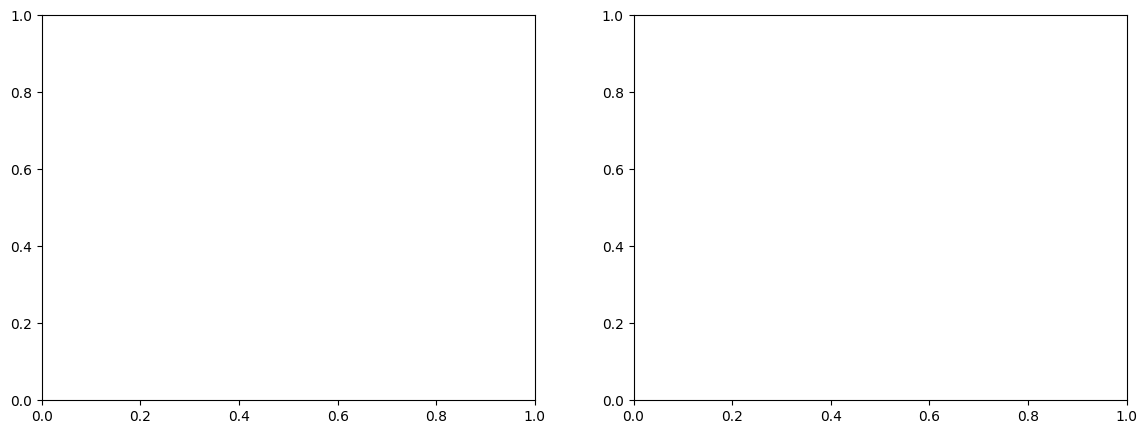

In [44]:
# Training Curves: Epoch vs MSE for DNN, ResNet, MLKM, ResKernelNet

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Define colors and styles
methods = {
    'DNN': {'train': dnn_trainloss, 'test': dnn_testloss, 'color': '#3498db', 'linestyle': '--'},
    'ResNet': {'train': res_trainloss, 'test': res_testloss, 'color': '#9b59b6', 'linestyle': '--'},
    'MLKM': {'train': mlkm_trainloss, 'test': mlkm_testloss, 'color': '#1abc9c', 'linestyle': '-'},
    'ResKernelNet': {'train': rkn_trainloss, 'test': rkn_testloss, 'color': '#e91e63', 'linestyle': '-'},
}

# Skip first N epochs to avoid initial large values
skip_epochs = 10

# Left plot: Test MSE
ax1 = axes[0]
for name, data in methods.items():
    epochs = range(skip_epochs, len(data['test']))
    ax1.plot(epochs, data['test'][skip_epochs:], 
             label=name, color=data['color'], linestyle=data['linestyle'], linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Test MSE', fontsize=12)
ax1.set_title('Test MSE vs Epoch', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# Right plot: Train MSE
ax2 = axes[1]
for name, data in methods.items():
    epochs = range(skip_epochs, len(data['train']))
    ax2.plot(epochs, data['train'][skip_epochs:], 
             label=name, color=data['color'], linestyle=data['linestyle'], linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Train MSE', fontsize=12)
ax2.set_title('Train MSE vs Epoch', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'training_curves.png'")
print(f"\nEpochs run: DNN={len(dnn_trainloss)}, ResNet={len(res_trainloss)}, MLKM={len(mlkm_trainloss)}, ResKernelNet={len(rkn_trainloss)}")


# Summary: All Methods Comparison

## Comprehensive Experiment: Different Hidden Dimensions
### Test all models with different HIDDEN_DIM configurations (h1=h2=h3).

In [45]:
# =============================================
# Wrapper Function to Run All Models with Different Hidden Dims
# =============================================

def run_all_models_with_hidden_dim(h1, h2, h3, D_values=[100, 200, 300, 400, 500]):
    """
    Run all models with specified hidden dimensions.
    For MLKM/ResKernelNet, test multiple D values and return the best (lowest test MSE).
    
    Returns dict with results for each model including CPU memory usage.
    """
    global HIDDEN_DIM1, HIDDEN_DIM2, HIDDEN_DIM3
    
    # Update global hidden dimensions
    HIDDEN_DIM1, HIDDEN_DIM2, HIDDEN_DIM3 = h1, h2, h3
    
    results = {}
    
    # --- DNN ---
    start = time.time()
    dnn_result, dnn_cpu_mb, dnn_cpu_peak = measure_memory_cpu(
        lambda: run_dnn(train_x, train_y, test_x, test_y, **TRAINING_CONFIG)
    )
    dnn_time = time.time() - start
    results['DNN'] = {
        'train_mse': dnn_result[0], 'test_mse': dnn_result[1], 
        'epochs': dnn_result[2], 'time': dnn_time, 'cpu_mb': dnn_cpu_mb, 'cpu_peak_mb': dnn_cpu_peak, 'best_D': None
    }
    
    # --- ResNet ---
    start = time.time()
    resnet_result, resnet_cpu_mb, resnet_cpu_peak = measure_memory_cpu(
        lambda: run_resnet(train_x, train_y, test_x, test_y, **TRAINING_CONFIG)
    )
    resnet_time = time.time() - start
    results['ResNet'] = {
        'train_mse': resnet_result[0], 'test_mse': resnet_result[1],
        'epochs': resnet_result[2], 'time': resnet_time, 'cpu_mb': resnet_cpu_mb, 'cpu_peak_mb': resnet_cpu_peak, 'best_D': None
    }
    
    # --- DKL ---
    start = time.time()
    dkl_result, dkl_cpu_mb, dkl_cpu_peak = measure_memory_cpu(
        lambda: run_dkl(train_x, train_y, test_x, test_y)
    )
    dkl_time = time.time() - start
    results['DKL'] = {
        'train_mse': dkl_result[0], 'test_mse': dkl_result[1],
        'epochs': 300, 'time': dkl_time, 'cpu_mb': dkl_cpu_mb, 'cpu_peak_mb': dkl_cpu_peak, 'best_D': None
    }
    
    # --- DGP ---
    start = time.time()
    dgp_result, dgp_cpu_mb, dgp_cpu_peak = measure_memory_cpu(
        lambda: run_dgp(train_x, train_y, test_x, test_y)
    )
    dgp_time = time.time() - start
    results['DGP'] = {
        'train_mse': dgp_result[0], 'test_mse': dgp_result[1],
        'epochs': 1000, 'time': dgp_time, 'cpu_mb': dgp_cpu_mb, 'cpu_peak_mb': dgp_cpu_peak, 'best_D': None
    }
    
    # --- MLKM (test all D values, pick best) ---
    best_mlkm = {'test_mse': float('inf')}
    for D in D_values:
        start = time.time()
        # Use default argument D=D to capture current value (avoid closure issue)
        mlkm_result, mlkm_cpu_mb, mlkm_cpu_peak = measure_memory_cpu(
            lambda D=D: run_mlkm(train_x, train_y, test_x, test_y, D1=D, D2=D, D3=D, **TRAINING_CONFIG)
        )
        mlkm_time = time.time() - start
        if mlkm_result[1] < best_mlkm['test_mse']:
            best_mlkm = {
                'train_mse': mlkm_result[0], 'test_mse': mlkm_result[1],
                'epochs': mlkm_result[2], 'time': mlkm_time, 'cpu_mb': mlkm_cpu_mb, 'cpu_peak_mb': mlkm_cpu_peak, 'best_D': D
            }
    results['MLKM'] = best_mlkm
    
    # --- ResKernelNet (test all D1 values, pick best) ---
    # Note: ResKernelNet has residual connections, so D2 must equal h1 and D3 must equal h2
    best_reskn = {'test_mse': float('inf')}
    for D in D_values:
        start = time.time()
        # Use default argument D=D to capture current value (avoid closure issue)
        reskn_result, reskn_cpu_mb, reskn_cpu_peak = measure_memory_cpu(
            lambda D=D: run_reskernelnet(train_x, train_y, test_x, test_y, 
                                         D1=D, D2=h1, D3=h2,
                                         **TRAINING_CONFIG)
        )
        reskn_time = time.time() - start
        if reskn_result[1] < best_reskn['test_mse']:
            best_reskn = {
                'train_mse': reskn_result[0], 'test_mse': reskn_result[1],
                'epochs': reskn_result[2], 'time': reskn_time, 'cpu_mb': reskn_cpu_mb, 'cpu_peak_mb': reskn_cpu_peak, 'best_D': D
            }
    results['ResKernelNet'] = best_reskn
    
    return results


# =============================================
# Run Experiments with Different Hidden Dimensions
# =============================================


HIDDEN_DIM_CONFIGS = [[32, 64, 16],  [32, 128, 32], [32, 128, 16], [64, 128, 16], [64, 128, 32], [16, 32, 16], [16, 64, 32]]
D_VALUES = list(range(32, 320, 16))

# Store all results
all_hidden_dim_results = {}

print("=" * 80)
print("COMPREHENSIVE EXPERIMENT: All Models × Hidden Dimensions")
print("=" * 80)
print(f"Hidden dim configs [h1, h2, h3]: {HIDDEN_DIM_CONFIGS}")
print(f"D values for MLKM: {D_VALUES}")
print("=" * 80)

for h_config in tqdm(HIDDEN_DIM_CONFIGS, desc="Testing Hidden Dims"):
    h1, h2, h3 = h_config
    config_str = f"({h1},{h2},{h3})"
    print(f"\n--- Testing h1={h1}, h2={h2}, h3={h3} ---")

    results = run_all_models_with_hidden_dim(h1, h2, h3, D_VALUES)
    all_hidden_dim_results[config_str] = results
    
    for method, res in results.items():
        d_info = f" (D={res['best_D']})" if res['best_D'] else ""
        print(f"  {method}: Test MSE = {res['test_mse']:.4f}{d_info}")

# Restore original hidden dimensions
HIDDEN_DIM1, HIDDEN_DIM2, HIDDEN_DIM3 = 16, 64, 32

print("\n" + "=" * 80)
print("All experiments completed!")
print("=" * 80)

COMPREHENSIVE EXPERIMENT: All Models × Hidden Dimensions
Hidden dim configs [h1, h2, h3]: [[32, 64, 16], [32, 128, 32], [32, 128, 16], [64, 128, 16], [64, 128, 32], [16, 32, 16], [16, 64, 32]]
D values for MLKM: [32, 48, 64, 80, 96, 112, 128, 144, 160, 176, 192, 208, 224, 240, 256, 272, 288, 304]


Testing Hidden Dims:   0%|          | 0/7 [00:00<?, ?it/s]


--- Testing h1=32, h2=64, h3=16 ---


ValueError: Input contains NaN.

## Summary: All Methods Comparison

In [ ]:
results_summary = pd.DataFrame({
    'Method': ['RF+Ridge', 'DNN', 'ResNet', 'DKL', 'DGP', 'MLKM', 'ResKernelNet'],
    'Train MSE': [
        rf_train_mse,
        dnn_train_mse,
        res_train_mse,
        dkl_train_mse,
        dgp_train_mse,
        mlkm_train_mse,
        rkn_train_mse
    ],
    'Test MSE': [
        rf_test_mse,
        dnn_test_mse,
        res_test_mse,
        dkl_test_mse,
        dgp_test_mse,
        mlkm_test_mse,
        rkn_test_mse
    ],
    'Time (s)': [
        rf_time,
        dnn_time,
        res_time,
        dkl_time,
        dgp_time,
        mlkm_time,
        rkn_time
    ],
    'CPU Δ (MB)': [
        rf_delta_cpu_mb,
        dnn_delta_cpu_mb,
        res_delta_cpu,
        dkl_delta_cpu,
        dgp_delta_cpu,
        mlkm_delta_cpu,
        rkn_delta_cpu
    ],
    'CPU Peak (MB)': [
        rf_peak_cpu_mb,
        dnn_peak_cpu_mb,
        res_peak_cpu,
        dkl_peak_cpu,
        dgp_peak_cpu,
        mlkm_peak_cpu,
        rkn_peak_cpu
    ],
    'GPU Peak (MB)': [
        None,
        dnn_peak_gpu_mb,
        res_peak_gpu,
        dkl_peak_gpu,
        dgp_peak_gpu,
        mlkm_peak_gpu,
        rkn_peak_gpu
    ]
})

print("=" * 80)
print("SUMMARY: All Methods Comparison on MSD Dataset")
print("=" * 80)
display(results_summary.round(4))

print("\n" + "=" * 80)
print("Ranked by Test MSE (lowest is best):")
print("=" * 80)
display(results_summary.sort_values('Test MSE').round(4))


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

methods_list = results_summary['Method']
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12', '#1abc9c', '#e91e63']

ax1 = axes[0, 0]
bars1 = ax1.bar(methods_list, results_summary['Test MSE'], color=colors, edgecolor='black', linewidth=1.2)
ax1.set_ylabel('Test MSE', fontsize=12)
ax1.set_title('Test MSE Comparison (lower is better)', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
for bar, val in zip(bars1, results_summary['Test MSE']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax2 = axes[0, 1]
bars2 = ax2.bar(methods_list, results_summary['Train MSE'], color=colors, edgecolor='black', linewidth=1.2)
ax2.set_ylabel('Train MSE', fontsize=12)
ax2.set_title('Train MSE Comparison', fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
for bar, val in zip(bars2, results_summary['Train MSE']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax3 = axes[1, 0]
bars3 = ax3.bar(methods_list, results_summary['Time (s)'], color=colors, edgecolor='black', linewidth=1.2)
ax3.set_ylabel('Time (seconds)', fontsize=12)
ax3.set_title('Runtime Comparison (lower is better)', fontsize=14, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
for bar, val in zip(bars3, results_summary['Time (s)']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}s', ha='center', va='bottom', fontsize=9)

ax4 = axes[1, 1]
bars4 = ax4.bar(methods_list, results_summary['CPU Peak (MB)'], color=colors, edgecolor='black', linewidth=1.2)
ax4.set_ylabel('CPU Peak Memory (MB)', fontsize=12)
ax4.set_title('CPU Peak Memory Usage Comparison', fontsize=14, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)
for bar, val in zip(bars4, results_summary['CPU Peak (MB)']):
    if val is not None:
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('msd_method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure saved as 'msd_method_comparison.png'")


In [ ]:
best_idx = results_summary['Test MSE'].idxmin()
best_method = results_summary.loc[best_idx]

print("=" * 60)
print("BEST PERFORMING METHOD (by Test MSE):")
print("=" * 60)
print(f"  Method:     {best_method['Method']}")
print(f"  Test MSE:   {best_method['Test MSE']:.6f}")
print(f"  Train MSE:  {best_method['Train MSE']:.6f}")
print(f"  Time:       {best_method['Time (s)']:.2f} seconds")
print(f"  CPU Δ:      {best_method['CPU Δ (MB)']:.2f} MB")
print(f"  CPU Peak:   {best_method['CPU Peak (MB)']:.2f} MB")
print("=" * 60)

results_summary['Efficiency (MSE/s)'] = results_summary['Test MSE'] / results_summary['Time (s)']
print("\nEfficiency Analysis (Test MSE per second - lower is better):")
display(results_summary[['Method', 'Test MSE', 'Time (s)', 'Efficiency (MSE/s)']].sort_values('Efficiency (MSE/s)').round(4))


## Comprehensive Experiment: Different Hidden Dimensions

Test all models with different HIDDEN_DIM configurations (h1=h2=h3).

In [ ]:
def run_all_models_with_hidden_dim(h1, h2, h3, D_values=[100, 200, 300, 400, 500]):
    """
    Run all models with specified hidden dimensions.
    For MLKM/ResKernelNet, test multiple D values and return the best (lowest test MSE).
    Returns dict with results for each model including CPU memory usage.
    """
    global HIDDEN_DIM1, HIDDEN_DIM2, HIDDEN_DIM3

    HIDDEN_DIM1, HIDDEN_DIM2, HIDDEN_DIM3 = h1, h2, h3

    results = {}

    # --- RF+Ridge ---
    start = time.time()
    rf_result, rf_cpu_mb, rf_cpu_peak = measure_memory_cpu(
        lambda: run_rf_ridge(train_x, train_y, test_x, test_y)
    )
    rf_time = time.time() - start
    results['RF+Ridge'] = {
        'train_mse': rf_result[0], 'test_mse': rf_result[1],
        'epochs': None, 'time': rf_time, 'cpu_mb': rf_cpu_mb, 'cpu_peak_mb': rf_cpu_peak, 'best_D': None
    }

    # --- DNN ---
    start = time.time()
    dnn_result, dnn_cpu_mb, dnn_cpu_peak = measure_memory_cpu(
        lambda: run_dnn(train_x, train_y, test_x, test_y, **TRAINING_CONFIG)
    )
    dnn_time = time.time() - start
    results['DNN'] = {
        'train_mse': dnn_result[0], 'test_mse': dnn_result[1],
        'epochs': dnn_result[2], 'time': dnn_time, 'cpu_mb': dnn_cpu_mb, 'cpu_peak_mb': dnn_cpu_peak, 'best_D': None
    }

    # --- ResNet ---
    start = time.time()
    resnet_result, resnet_cpu_mb, resnet_cpu_peak = measure_memory_cpu(
        lambda: run_resnet(train_x, train_y, test_x, test_y, **TRAINING_CONFIG)
    )
    resnet_time = time.time() - start
    results['ResNet'] = {
        'train_mse': resnet_result[0], 'test_mse': resnet_result[1],
        'epochs': resnet_result[2], 'time': resnet_time, 'cpu_mb': resnet_cpu_mb, 'cpu_peak_mb': resnet_cpu_peak, 'best_D': None
    }

    # --- DKL ---
    start = time.time()
    dkl_result, dkl_cpu_mb, dkl_cpu_peak = measure_memory_cpu(
        lambda: run_dkl(train_x, train_y, test_x, test_y)
    )
    dkl_time = time.time() - start
    results['DKL'] = {
        'train_mse': dkl_result[0], 'test_mse': dkl_result[1],
        'epochs': 300, 'time': dkl_time, 'cpu_mb': dkl_cpu_mb, 'cpu_peak_mb': dkl_cpu_peak, 'best_D': None
    }

    # --- DGP ---
    start = time.time()
    dgp_result, dgp_cpu_mb, dgp_cpu_peak = measure_memory_cpu(
        lambda: run_dgp(train_x, train_y, test_x, test_y)
    )
    dgp_time = time.time() - start
    results['DGP'] = {
        'train_mse': dgp_result[0], 'test_mse': dgp_result[1],
        'epochs': 1000, 'time': dgp_time, 'cpu_mb': dgp_cpu_mb, 'cpu_peak_mb': dgp_cpu_peak, 'best_D': None
    }

    # --- MLKM (test all D values, pick best) ---
    best_mlkm = {'test_mse': float('inf')}
    for D in D_values:
        start = time.time()
        mlkm_result, mlkm_cpu_mb, mlkm_cpu_peak = measure_memory_cpu(
            lambda D=D: run_mlkm(train_x, train_y, test_x, test_y, D1=D, D2=D, D3=D, **TRAINING_CONFIG)
        )
        mlkm_time = time.time() - start
        if mlkm_result[1] < best_mlkm['test_mse']:
            best_mlkm = {
                'train_mse': mlkm_result[0], 'test_mse': mlkm_result[1],
                'epochs': mlkm_result[2], 'time': mlkm_time, 'cpu_mb': mlkm_cpu_mb, 'cpu_peak_mb': mlkm_cpu_peak, 'best_D': D
            }
    results['MLKM'] = best_mlkm

    # --- ResKernelNet (test all D values, pick best) ---
    best_rkn = {'test_mse': float('inf')}
    for D in D_values:
        start = time.time()
        rkn_result, rkn_cpu_mb, rkn_cpu_peak = measure_memory_cpu(
            lambda D=D: run_reskernelnet(train_x, train_y, test_x, test_y, D1=D, **TRAINING_CONFIG)
        )
        rkn_time = time.time() - start
        if rkn_result[1] < best_rkn['test_mse']:
            best_rkn = {
                'train_mse': rkn_result[0], 'test_mse': rkn_result[1],
                'epochs': rkn_result[2], 'time': rkn_time, 'cpu_mb': rkn_cpu_mb, 'cpu_peak_mb': rkn_cpu_peak, 'best_D': D
            }
    results['ResKernelNet'] = best_rkn

    return results

# Run experiment with different hidden dimension configurations
hidden_dim_configs = [
    (16, 32, 8),
    (32, 64, 16),
    (64, 128, 32),
    (128, 256, 64),
]

all_hidden_dim_results = {}
for h1, h2, h3 in hidden_dim_configs:
    config_str = f"[{h1},{h2},{h3}]"
    print(f"\n{'='*60}")
    print(f"Running all models with HIDDEN_DIM = {config_str}")
    print(f"{'='*60}")
    all_hidden_dim_results[config_str] = run_all_models_with_hidden_dim(h1, h2, h3)

# Restore default
HIDDEN_DIM1, HIDDEN_DIM2, HIDDEN_DIM3 = 32, 64, 16


In [ ]:
rows = []
for config_str, methods in all_hidden_dim_results.items():
    for method, res in methods.items():
        rows.append({
            'Hidden Config': config_str,
            'Method': method,
            'Train MSE': res['train_mse'],
            'Test MSE': res['test_mse'],
            'Epochs': res['epochs'],
            'Time (s)': res['time'],
            'CPU Δ (MB)': res['cpu_mb'],
            'CPU Peak (MB)': res['cpu_peak_mb'],
            'Best D': res['best_D']
        })

hidden_dim_df = pd.DataFrame(rows)

print("=" * 100)
print("FULL RESULTS: All Models x Hidden Dimensions [h1, h2, h3]")
print("=" * 100)
display(hidden_dim_df.round(4))

print("\n" + "=" * 100)
print("PIVOT TABLE: Test MSE (rows=Method, cols=Hidden Config)")
print("=" * 100)
pivot_test = hidden_dim_df.pivot(index='Method', columns='Hidden Config', values='Test MSE')
display(pivot_test.round(4))

print("\n" + "=" * 100)
print("BEST CONFIGURATION FOR EACH METHOD")
print("=" * 100)
best_per_method = hidden_dim_df.loc[hidden_dim_df.groupby('Method')['Test MSE'].idxmin()]
display(best_per_method.sort_values('Test MSE').round(4))


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = {'RF+Ridge': '#2ecc71', 'DNN': '#3498db', 'ResNet': '#9b59b6',
          'DKL': '#e74c3c', 'DGP': '#f39c12', 'MLKM': '#1abc9c', 'ResKernelNet': '#e91e63'}
markers = {'RF+Ridge': 'o', 'DNN': 's', 'ResNet': 'D',
           'DKL': 'p', 'DGP': 'h', 'MLKM': '^', 'ResKernelNet': 'v'}

config_labels = list(all_hidden_dim_results.keys())
x_positions = range(len(config_labels))

ax1 = axes[0]
for method in colors.keys():
    data = hidden_dim_df[hidden_dim_df['Method'] == method]
    y_vals = [data[data['Hidden Config'] == cfg]['Test MSE'].values[0] for cfg in config_labels]
    ax1.plot(x_positions, y_vals, color=colors[method],
             marker=markers[method], linewidth=2, markersize=10, label=method)
ax1.set_xlabel('Hidden Config (h1, h2, h3)', fontsize=12)
ax1.set_ylabel('Test MSE', fontsize=12)
ax1.set_title('Test MSE vs Hidden Config', fontsize=14)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(list(x_positions))
ax1.set_xticklabels(config_labels, rotation=45, ha='right')

ax2 = axes[1]
for method in colors.keys():
    data = hidden_dim_df[hidden_dim_df['Method'] == method]
    y_vals = [data[data['Hidden Config'] == cfg]['Train MSE'].values[0] for cfg in config_labels]
    ax2.plot(x_positions, y_vals, color=colors[method],
             marker=markers[method], linewidth=2, markersize=10, label=method)
ax2.set_xlabel('Hidden Config (h1, h2, h3)', fontsize=12)
ax2.set_ylabel('Train MSE', fontsize=12)
ax2.set_title('Train MSE vs Hidden Config', fontsize=14)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(list(x_positions))
ax2.set_xticklabels(config_labels, rotation=45, ha='right')

ax3 = axes[2]
sns.heatmap(pivot_test, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=ax3)
ax3.set_title('Test MSE Heatmap', fontsize=14)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('msd_hidden_dim_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to: msd_hidden_dim_comparison.png")


## Experiment: MLKM with Different RFF Dimensions

In [ ]:
HIDDEN_DIM1, HIDDEN_DIM2, HIDDEN_DIM3 = 32, 64, 16

D_values = list(range(16, 320, 16))

mlkm_dimension_results = {
    'D': [], 'train_mse': [], 'test_mse': [], 'epochs': [],
    'time': [], 'cpu_delta_mb': [], 'cpu_peak_mb': [], 'gpu_peak_mb': []
}

print("=" * 60)
print("MLKM Experiments with Different RFF Dimensions")
print(f"Hidden layers: {HIDDEN_DIM1} -> {HIDDEN_DIM2} -> {HIDDEN_DIM3}")
print("=" * 60)

for D in D_values:
    print(f"\n--- Running MLKM with D1=D2=D3={D} ---")
    def mlkm_core_d():
        return run_mlkm(train_x, train_y, test_x, test_y, D1=D, D2=D, D3=D, **TRAINING_CONFIG)
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    ((result, peak_gpu), delta_cpu, peak_cpu), elapsed_time = measure_time(
        lambda: measure_memory_cpu(
            lambda: measure_memory_gpu(mlkm_core_d)
        )
    )
    train_mse, test_mse, epochs, net, optimizer, trainloss, testloss, device = result
    mlkm_dimension_results['D'].append(D)
    mlkm_dimension_results['train_mse'].append(train_mse)
    mlkm_dimension_results['test_mse'].append(test_mse)
    mlkm_dimension_results['epochs'].append(epochs)
    mlkm_dimension_results['time'].append(elapsed_time)
    mlkm_dimension_results['cpu_delta_mb'].append(delta_cpu)
    mlkm_dimension_results['cpu_peak_mb'].append(peak_cpu)
    mlkm_dimension_results['gpu_peak_mb'].append(peak_gpu)
    print(f"  Train MSE: {train_mse:.6f}")
    print(f"  Test MSE:  {test_mse:.6f}")
    print(f"  Epochs:    {epochs}")
    print(f"  Time (s):  {elapsed_time:.2f}")

print("\n" + "=" * 60)
print("All experiments completed!")
print("=" * 60)

results_df = pd.DataFrame(mlkm_dimension_results)
results_df.columns = ['D (RFF dim)', 'Train MSE', 'Test MSE', 'Epochs', 'Time (s)', 'CPU ΔMB', 'CPU Peak (MB)', 'GPU peak MB']

print("\n" + "=" * 80)
print("MLKM Results Summary: Different RFF Dimensions (D1=D2=D3)")
print("=" * 80)
print(results_df.to_string(index=False))
print("=" * 80)

results_csv_path = 'msd_mlkm_dimension_experiment_results.csv'
results_df.to_csv(results_csv_path, index=False)
print(f"\nResults saved to: {results_csv_path}")


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax1 = axes[0]
ax1.plot(mlkm_dimension_results['D'], mlkm_dimension_results['train_mse'],
         'b-o', label='Train MSE', linewidth=2, markersize=6)
ax1.plot(mlkm_dimension_results['D'], mlkm_dimension_results['test_mse'],
         'r-s', label='Test MSE', linewidth=2, markersize=6)
ax1.set_xlabel('RFF Dimension (D1=D2=D3)', fontsize=12)
ax1.set_ylabel('MSE', fontsize=12)
ax1.set_title('MLKM: MSE vs RFF Dimension', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.bar(mlkm_dimension_results['D'], mlkm_dimension_results['time'],
        color='steelblue', width=12)
ax2.set_xlabel('RFF Dimension (D1=D2=D3)', fontsize=12)
ax2.set_ylabel('Time (seconds)', fontsize=12)
ax2.set_title('MLKM: Training Time vs RFF Dimension', fontsize=14)
ax2.grid(True, alpha=0.3, axis='y')

ax3 = axes[2]
ax3.bar(mlkm_dimension_results['D'], mlkm_dimension_results['epochs'],
        color='forestgreen', width=12)
ax3.set_xlabel('RFF Dimension (D1=D2=D3)', fontsize=12)
ax3.set_ylabel('Epochs', fontsize=12)
ax3.set_title('MLKM: Epochs Run vs RFF Dimension', fontsize=14)
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('msd_mlkm_dimension_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved to: msd_mlkm_dimension_plots.png")
